In [1]:
import pyreadstat
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from collections import Counter
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from collections import Counter


# EDA

In [2]:
df_ch = pyreadstat.read_sav('C:/Users/dbastola2022/OneDrive - Florida Atlantic University/Academics/Research/Malnutrition/NDHS/Work Progress/Python/malnutrition/MICS/ch.sav')[0]
# data = pd.read_spss('/workspaces/malnutrition/MICS/ch.sav')

# df_bh = pyreadstat.read_sav('/workspaces/malnutrition/MICS/bh.sav')[0]
# df_hh = pyreadstat.read_sav('/workspaces/malnutrition/MICS/hh.sav')[0]
# df_wm = pyreadstat.read_sav('/workspaces/malnutrition/MICS/wm.sav')[0]
# df_fs = pyreadstat.read_sav('/workspaces/malnutrition/MICS/fs.sav')[0]
# df_mn = pyreadstat.read_sav('/workspaces/malnutrition/MICS/mn.sav')[0]
# df_hl = pyreadstat.read_sav('/workspaces/malnutrition/MICS/hl.sav')[0]

# Renaming the columns
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

# Remove rows with coded entries in each column
df2 = df1.copy()
df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2.dropna(inplace=True)

df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]

df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)
df2.head(10)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,7.8,1.0,2.0,2.0,2.0,1.0,5.0,2.0,1.0,1.0,1
2,2.0,11.1,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,0
3,1.0,9.3,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,0
5,0.0,6.9,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,0
6,1.0,10.5,1.0,2.0,2.0,2.0,1.0,5.0,2.0,1.0,1.0,0
7,1.0,10.4,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,0
10,1.0,8.8,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1
13,1.0,9.7,1.0,2.0,2.0,2.0,1.0,0.0,2.0,1.0,1.0,1
15,1.0,10.3,1.0,2.0,2.0,2.0,1.0,5.0,2.0,1.0,1.0,1
16,1.0,7.7,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1


In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3581 entries, 0 to 6747
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   child_age               3581 non-null   float64
 1   child_weight            3581 non-null   float64
 2   ever_breastfed          3581 non-null   float64
 3   diarrhoea_last_2_weeks  3581 non-null   float64
 4   fever_last_2_weeks      3581 non-null   float64
 5   area                    3581 non-null   float64
 6   child_sex               3581 non-null   float64
 7   mother_education        3581 non-null   float64
 8   health_insurance        3581 non-null   float64
 9   province                3581 non-null   float64
 10  wealth_index            3581 non-null   float64
 11  malnurished             3581 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 363.7 KB


# Artificial Neural Network

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

In [9]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [ ]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['recall'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,  
    epochs=100,            
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


c:\Users\dbastola2022\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7935 - recall: 0.3379 - val_loss: 0.6718 - val_recall: 0.3678
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6798 - recall: 0.3353 - val_loss: 0.6681 - val_recall: 0.4713
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6722 - recall: 0.3311 - val_loss: 0.6655 - val_recall: 0.5441
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6637 - recall: 0.4640 - val_loss: 0.6600 - val_recall: 0.4176
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6603 - recall: 0.3466 - val_loss: 0.6579 - val_recall: 0.6130
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6466 - recall: 0.4017 - val_loss: 0.6521 - val_recall: 0.6437
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6572 - recall: 0.4106 - val_loss: 0.6437 - val_recall: 0.5134
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6343 - recall: 0.4304 - val_loss: 0.6435 - val_recall: 0.3410
Epoch 9/100


In [23]:
from sklearn.metrics import classification_report

# Get predicted probabilities
y_probs = model.predict(X_test)

# Convert to class labels
y_pred = (y_probs > 0.5).astype("int")

# Print classification report
print(classification_report(y_test, y_pred))


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           0       0.71      0.79      0.75       397
           1       0.70      0.60      0.64       320

    accuracy                           0.71       717
   macro avg       0.70      0.70      0.70       717
weighted avg       0.71      0.71      0.70       717



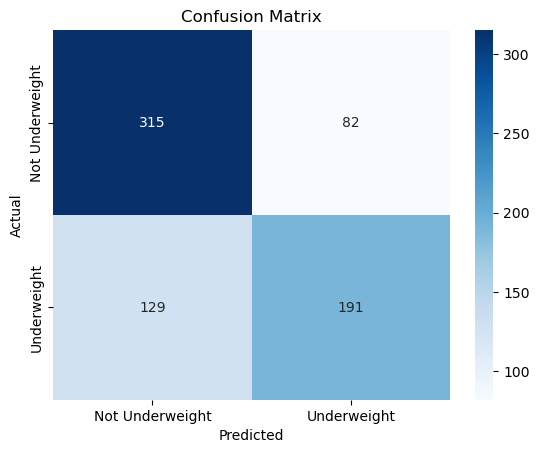

In [24]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Underweight', 'Underweight'], yticklabels=['Not Underweight', 'Underweight'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay

# Use model.predict() and flatten to 1D
y_probas = model.predict(X_test).ravel()

# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Average Precision: 0.7194686735818032


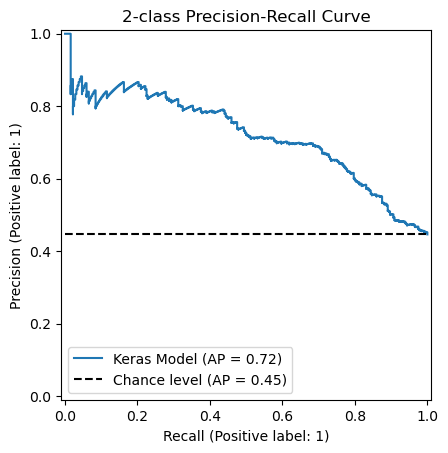

In [29]:
# Create precision-recall display from predictions
display = PrecisionRecallDisplay.from_predictions(y_test, y_probas, name="Keras Model", plot_chance_level=True)
display.ax_.set_title('2-class Precision-Recall Curve')
plt.show()

In [15]:
display = PrecisionRecallDisplay.from_estimator(
    model,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

NotFittedError: This Sequential instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.